## SARIMA Model - Time Series Analysis (Series 2)
### Objective
This notebook analyzes the weekly time series of Altres IRA (Other Acute Respiratory Infections) cases for individuals aged 15 years and older in the BCN Nord region over the period 2012–2024.
The variable Altres IRA corresponds to an aggregated series, combining multiple respiratory infection diagnoses that are not classified into specific categories such as influenza or pneumonia. Therefore, it reflects a general measure of respiratory infection incidence in the population.

The analysis is conducted following the Box-Jenkins methodology, including model identification, estimation, diagnostic checking, and forecasting.

### Methodology
1. Exploratory analysis
2. Stationarity analysis
3. Model identification
4. Model estimation
5. Validation
6. Forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

### Data Filtering

Is it selected the subset corresponding to:
- Diagnosis: Altres Ira
- Region: Barcelona Metropolitana Nord
- Age group: 15+

In [2]:
df_serie = df[
    (df["diagnostic"] == "Altres IRA") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

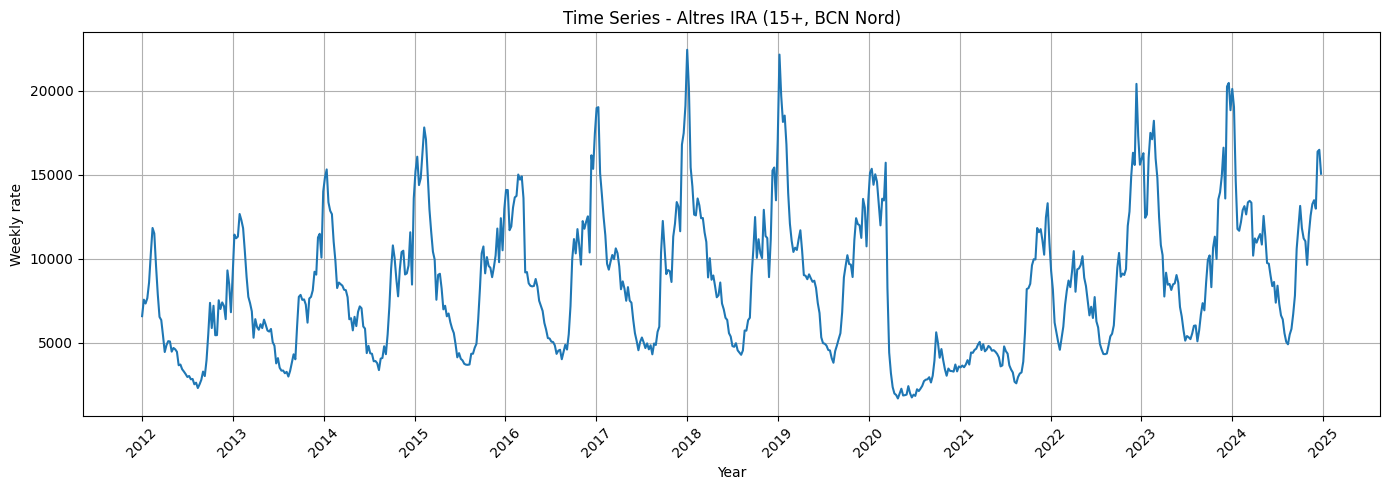

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Time Series - Altres IRA (15+, BCN Nord)")
plt.ylabel("Weekly rate")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Train-Test Split

The dataset is split into:
- Training set: used for model estimation (2012-2019)
- Test set: used for validation and forecasting performance (2020-2024)

In [4]:
serie_2 = serie.copy()

train = serie_2[serie_2.index < "2020-01-01"]
test  = serie_2[serie_2.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


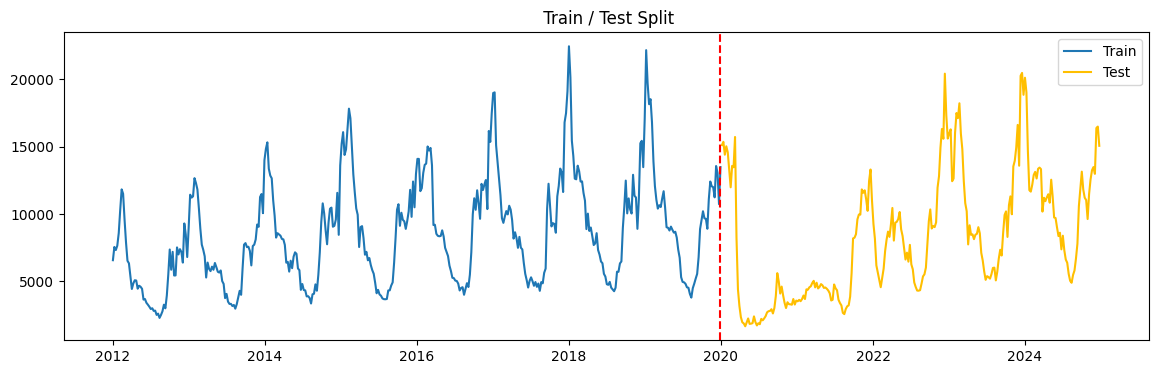

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title(" Train / Test Split")
plt.show()

## Exploratory Analysis
The original time series shows:

- a clear seasonal pattern,
- changes in variability over time,
- and a possible smooth trend component.

Since the variability appears to increase with the level of the series, a variance-stabilizing transformation is considered before modeling.

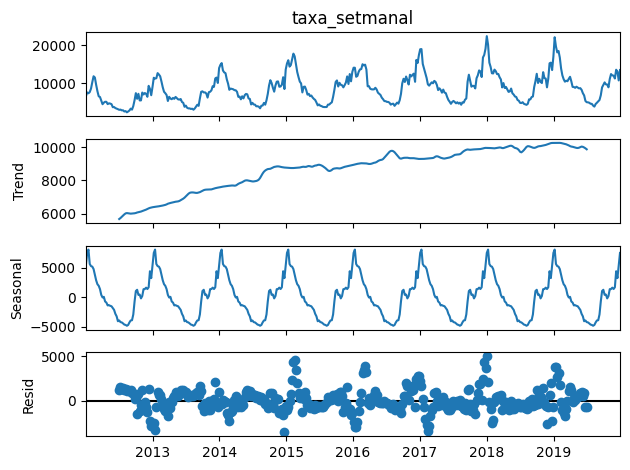

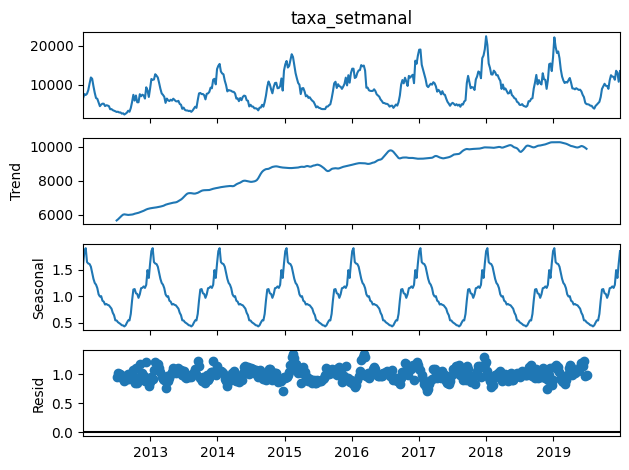

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

decompm = seasonal_decompose(train, model="multiplicative", period=52)
decompm.plot()
plt.show()

Global mean (train): 8550.028668482193
Global variance (train): 14871678.95775331

 Mean per year:
date
2012-12-31    5708.116743
2013-12-31    7086.500405
2014-12-31    7937.845806
2015-12-31    8945.744775
2016-12-31    9508.455428
2017-12-31    9469.804797
2018-12-31    9922.266702
2019-12-31    9849.757651
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31    6.010920e+06
2013-12-31    8.475888e+06
2014-12-31    9.373031e+06
2015-12-31    1.601566e+07
2016-12-31    1.431834e+07
2017-12-31    1.646238e+07
2018-12-31    1.667655e+07
2019-12-31    1.722288e+07
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


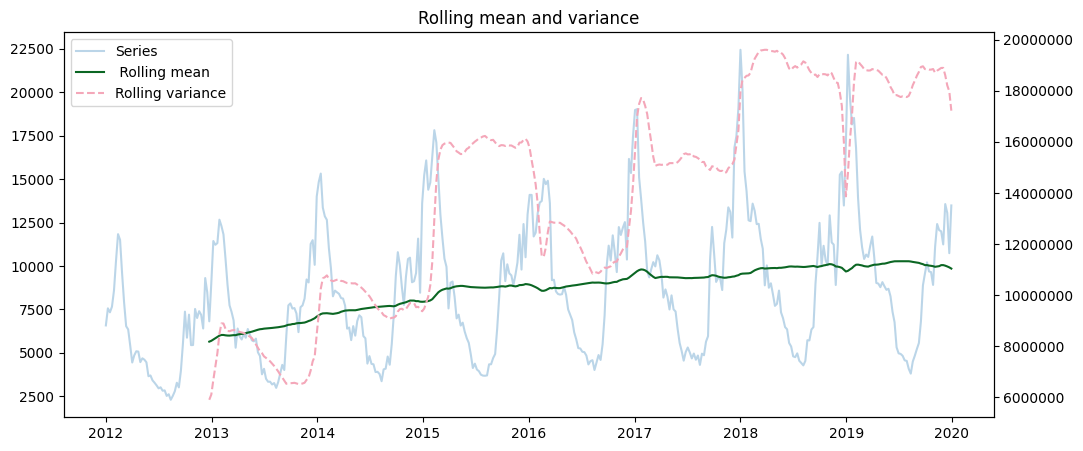

In [7]:
print("Global mean (train):", train.mean())
print("Global variance (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_mean, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Log Transformation

Because the variance is not stable in the original scale, a logarithmic transformation is applied.

After transformation, the series shows a more homogeneous variability over time. Therefore, the analysis and subsequent SARIMA modeling are carried out on the log-transformed series

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


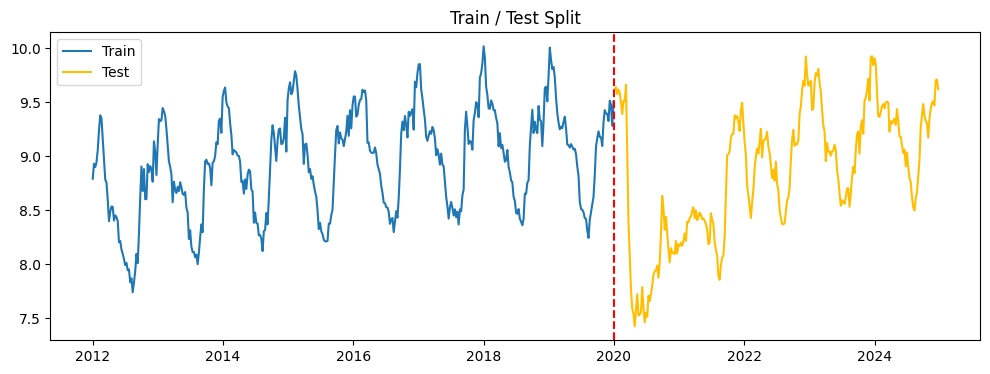

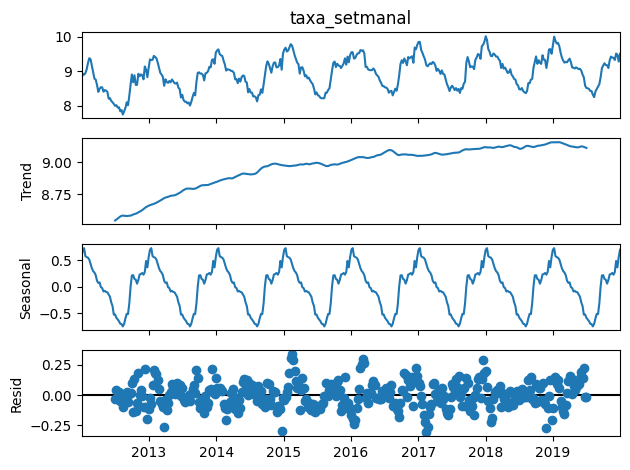

Global mean (train_log): 8.94973617768974
Global variance (train_log): 0.21770649210849538

 Mean per year:
date
2012-12-31    8.555711
2013-12-31    8.780633
2014-12-31    8.904041
2015-12-31    8.994350
2016-12-31    9.074271
2017-12-31    9.067446
2018-12-31    9.118664
2019-12-31    9.107102
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31    0.198757
2013-12-31    0.180062
2014-12-31    0.159242
2015-12-31    0.224150
2016-12-31    0.185267
2017-12-31    0.182477
2018-12-31    0.176279
2019-12-31    0.186979
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


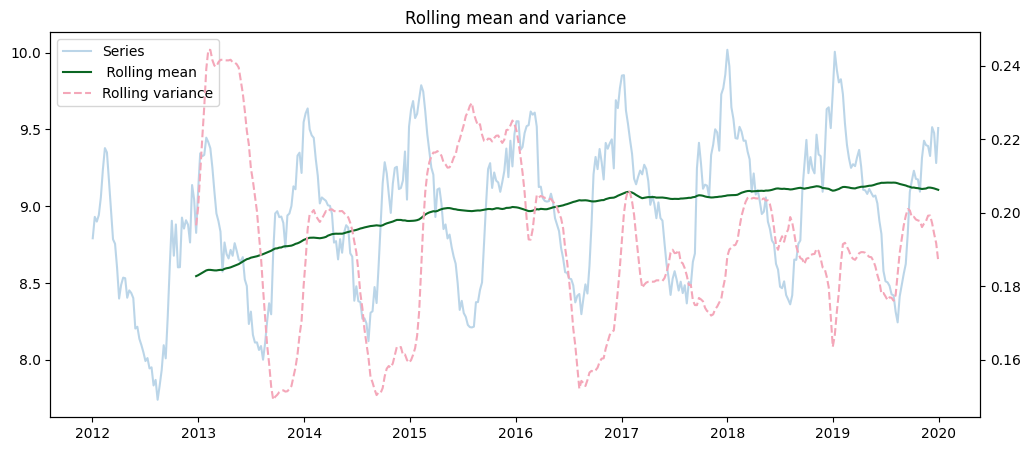

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(12,4))

plt.plot(train_log, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Train / Test Split")
plt.show()

decomp_log = seasonal_decompose(train_log, model="additive", period=52)
decomp_log.plot()
plt.show()

print("Global mean (train_log):", train_log.mean())
print("Global variance (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_meanlog, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Original ACF

After the decomposition, the ACF of the original series is examined to assess the possible presence of seasonality.

Significant peaks at seasonal lags, particularly around (m = 52), suggest a clear annual seasonal pattern. This provides an initial indication that seasonal differencing may be needed.

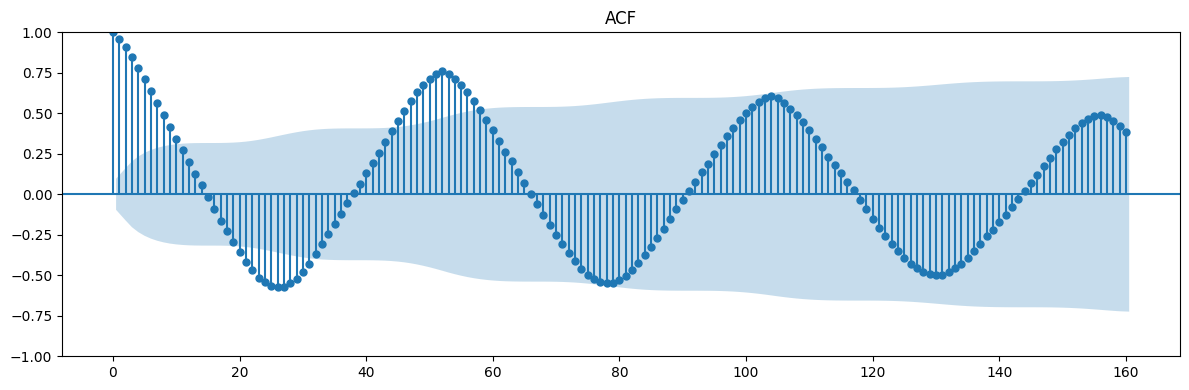

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

### Stationarity Analysis

The following statistical tests are applied:

- Augmented Dickey-Fuller (ADF)
- KPSS test

### Interpretation

- ADF: H0 = non-stationary
- KPSS: H0 = stationary

Results:

- ADF test: the null hypothesis of non-stationarity is rejected.
- KPSS test: the null hypothesis of stationarity is rejected.

Taken together, these results are contradictory: the ADF test suggests stationarity, while the KPSS test indicates that the series is still not stationary. Therefore, the series cannot be considered fully stationary at this stage, and additional differencing is required.

In [10]:
dftest = adfuller(train_log, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Value : ", dftest[1])

stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-value:", p_value)

1. ADF :  -5.876880079704801
P-Value :  3.1443172569573714e-07

2. KPSS : 0.5664849914712139
P-value: 0.026692569488465333


### Descriptive Analysis

To complement the statistical tests, the rolling mean and rolling variance were examined on the log-transformed series.

The rolling mean still shows a slight upward trend over time, indicating that the series is not yet stationary in mean. This is consistent with the presence of a deterministic trend observed in the original series.

Regarding variability, the variance per year is considerably more stable after the logarithmic transformation, fluctuating within a relatively narrow range compared to the original scale. Similarly, the rolling variance no longer exhibits a clear increasing pattern over time, suggesting that the transformation has successfully reduced heteroscedasticity.
Although the variance is not perfectly constant, the dependence between the level of the series and its variability has been significantly mitigated.

Overall, these results indicate that the logarithmic transformation improves the stability of the variance, but the series still requires differencing to achieve stationarity in mean.

### Seasonal Differencing Check

To further assess whether seasonal differencing is appropriate, the series after applying one seasonal difference, is compared with the original series, and the ACF is examined again.

After applying seasonal differencing, the annual repeating pattern is substantially attenuated, and the seasonal peaks in the ACF become notably weaker. This supports the choice of seasonal differencing of order one, D = 1.

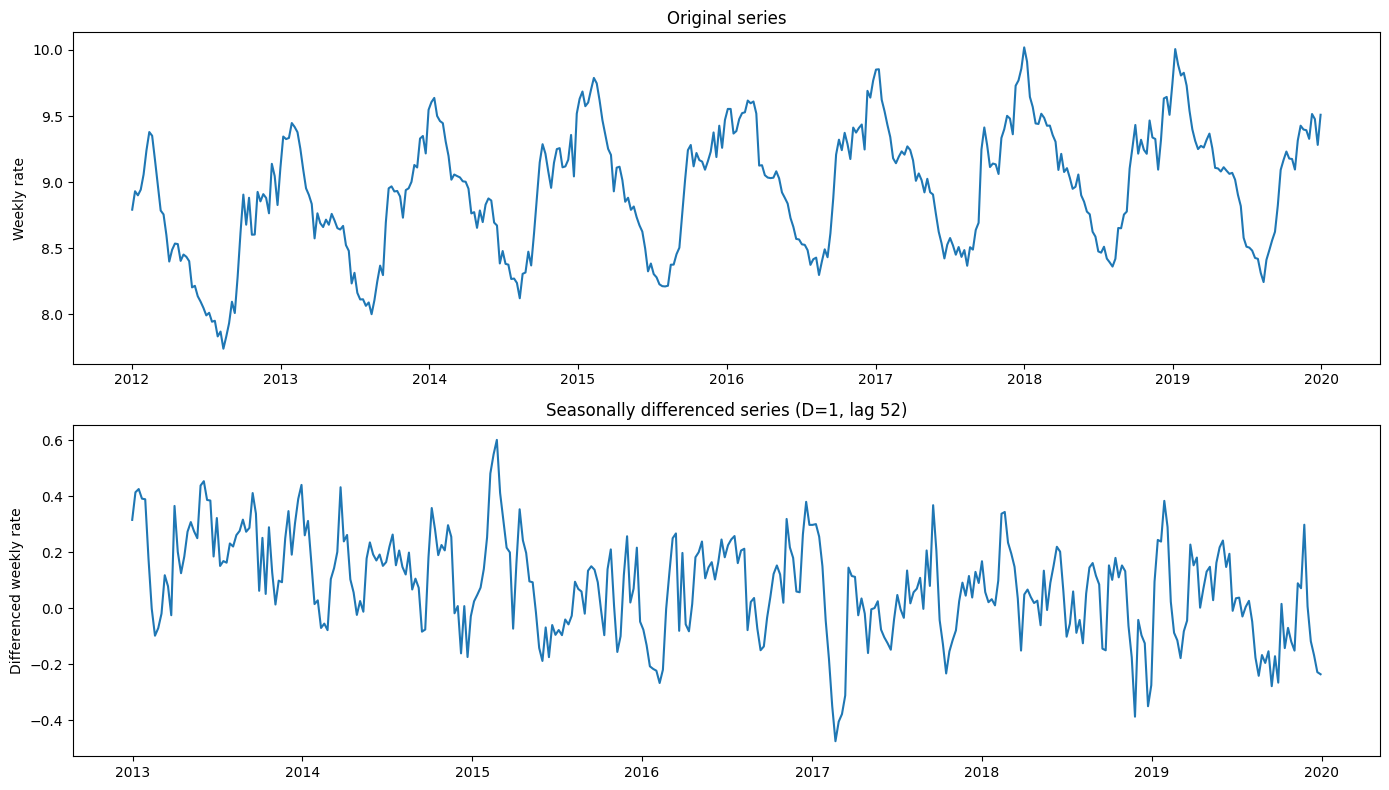

In [11]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Original series")
axes[0].set_ylabel("Weekly rate")

axes[1].plot(serie_D1)
axes[1].set_title("Seasonally differenced series (D=1, lag 52)")
axes[1].set_ylabel("Differenced weekly rate")

plt.tight_layout()
plt.show()

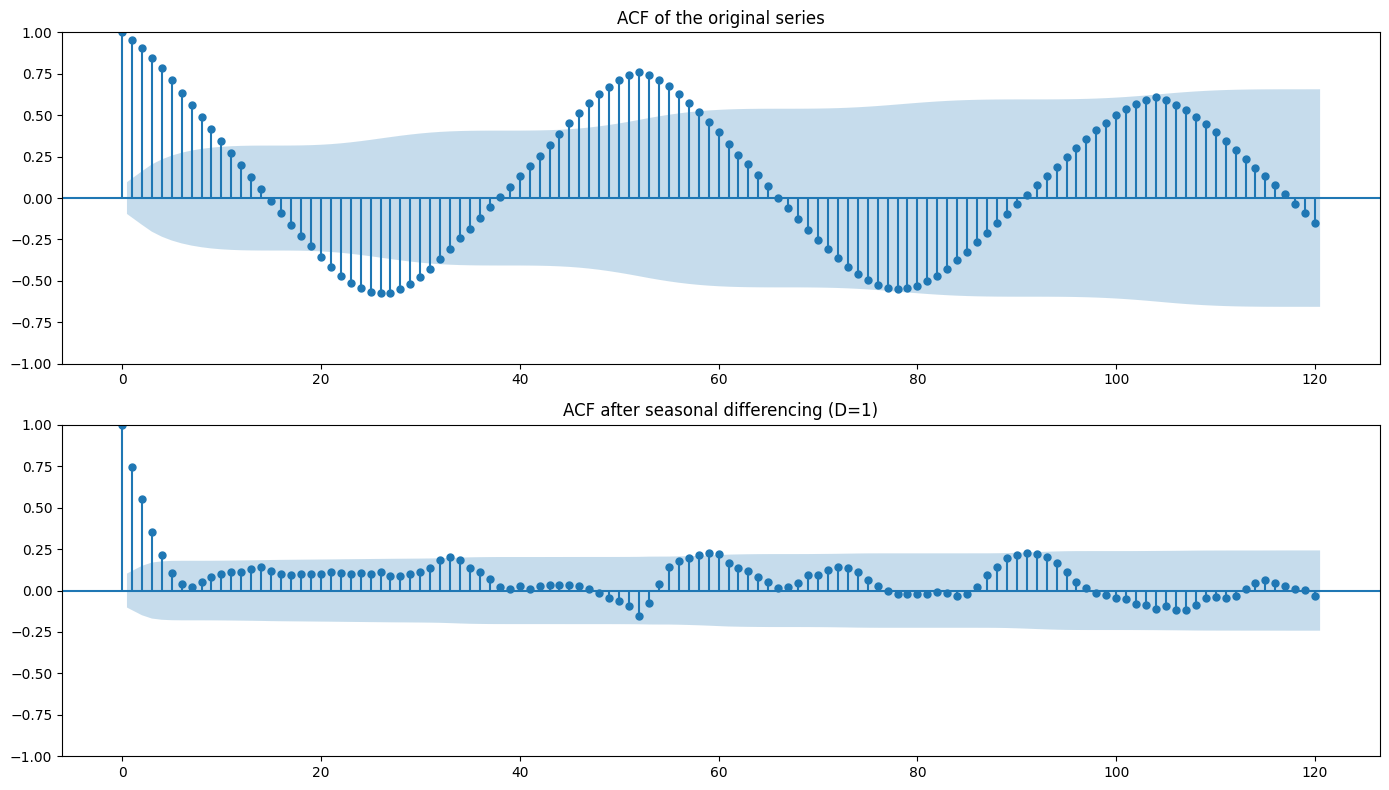

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF of the original series")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF after seasonal differencing (D=1)")

plt.tight_layout()
plt.show()

### Differencing Selection

After the logarithmic transformation, the variance becomes notably more stable, but the mean still shows a slight upward evolution over time.

ADF and KPSS provide conflicting evidence on stationarity, so the choice of regular differencing is supported by additional graphical diagnostics. In particular, after applying only seasonal differencing (\(D=1\)), the ACF still exhibits relevant short-term persistence. Once a first-order regular difference is also applied, the ACF and PACF become much more stable and do not show clear signs of severe over-differencing.

Therefore, the final specification adopts both regular and seasonal differencing (\(d=1, D=1\)).

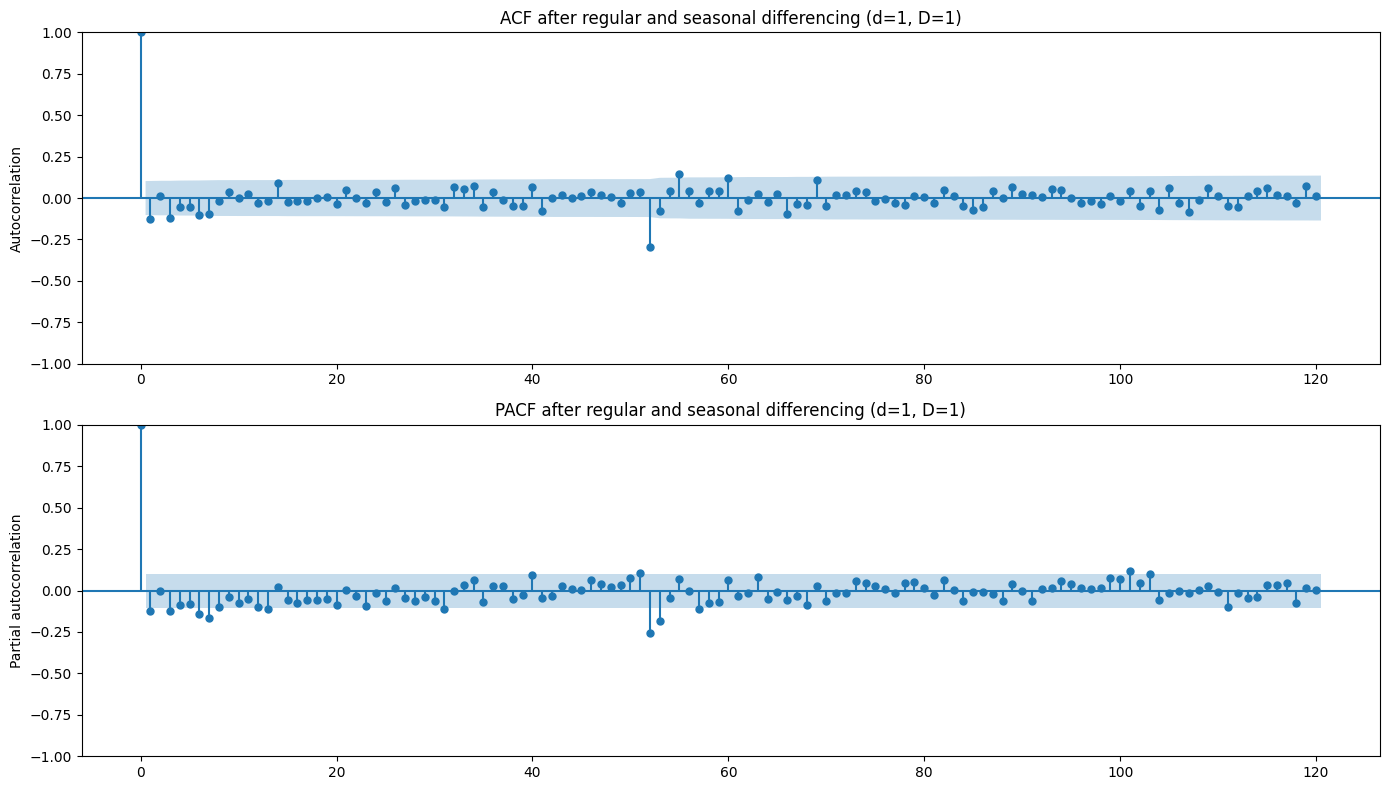

In [13]:
serie_d1D1 = serie_D1.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_d1D1, lags=120, ax=axes[0])
axes[0].set_title("ACF after regular and seasonal differencing (d=1, D=1)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(serie_d1D1, lags=120, ax=axes[1])
axes[1].set_title("PACF after regular and seasonal differencing (d=1, D=1)")
axes[1].set_ylabel("Partial autocorrelation")

plt.tight_layout()
plt.show()

### ACF and PACF Analysis

Based on the ACF and PACF of the log-transformed and differenced series \((d=1, D=1)\), the autocorrelation structure appears relatively simple. The ACF shows a negative spike at lag 1 and a clear seasonal spike at lag 52, suggesting the presence of a non-seasonal MA component and a seasonal MA component. The PACF does not show a strong cut-off pattern, so only low-order AR terms are considered.

Therefore, the candidate models are chosen among parsimonious SARIMA specifications, with special attention to models including MA(1) and seasonal MA(1) terms.

## Model Selection

I test several SARIMA models based on ACF/PACF insights and compare them using AIC. 

Although the ACF of the differenced series displayed a seasonal spike at lag 52, suggesting that a seasonal MA term (Q=1) could be considered, the fitted models including this component systematically produced substantially higher AIC values than the corresponding models with Q=0.

Therefore, the final candidate set focused on the more parsimonious seasonal specification without a seasonal MA term.
Each model is fitted using the training data.

In [14]:
models = [
    ((0,1,1), (0,1,1,52)),
    ((1,1,1), (0,1,1,52)),
    ((1,1,1), (0,1,0,52)),
    ((1,1,2), (0,1,0,52)),
    ((1,1,3), (0,1,0,52)),
    ((1,1,2), (0,1,1,52)), 
    ((2,1,2), (0,1,0,52)),
    
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA{order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA{order}{seasonal_order}")

print("\n Best model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA(0, 1, 1)(0, 1, 1, 52)
AIC: -473.73378327119457
----------------------------------------
Model SARIMA(1, 1, 1)(0, 1, 1, 52)
AIC: -472.2023855011214
----------------------------------------
Model SARIMA(1, 1, 1)(0, 1, 0, 52)
AIC: -525.067946044383
----------------------------------------
Model SARIMA(1, 1, 2)(0, 1, 0, 52)
AIC: -520.8622930114864
----------------------------------------
Model SARIMA(1, 1, 3)(0, 1, 0, 52)
AIC: -523.0627031045083
----------------------------------------
Model SARIMA(1, 1, 2)(0, 1, 1, 52)
AIC: -463.6063364665524
----------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model SARIMA(2, 1, 2)(0, 1, 0, 52)
AIC: -519.7202466265593
----------------------------------------

 Best model:
((1, 1, 1), (0, 1, 0, 52))
AIC: -525.067946044383


In [15]:
model1 = SARIMAX(train_log,
                order=(1,1,1),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 52)   Log Likelihood                 265.534
Date:                             Sat, 11 Apr 2026   AIC                           -525.068
Time:                                     18:32:25   BIC                           -513.385
Sample:                                 01-02-2012   HQIC                          -520.424
                                      - 12-30-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7145      0.039     18.366      0.000       0.638       0.791
ma.L1         -0.9816      

In [16]:
model2 = SARIMAX(train_log,
                order=(1,1,2),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(0, 1, [], 52)   Log Likelihood                 264.431
Date:                             Sat, 11 Apr 2026   AIC                           -520.862
Time:                                     18:32:26   BIC                           -505.296
Sample:                                 01-02-2012   HQIC                          -514.674
                                      - 12-30-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7025      0.055     12.822      0.000       0.595       0.810
ma.L1         -0.9584      

In [17]:
model3 = SARIMAX(train_log,
                order=(1,1,3),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 3)x(0, 1, [], 52)   Log Likelihood                 266.531
Date:                             Sat, 11 Apr 2026   AIC                           -523.063
Time:                                     18:32:28   BIC                           -503.618
Sample:                                 01-02-2012   HQIC                          -515.332
                                      - 12-30-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5796      0.093      6.246      0.000       0.398       0.761
ma.L1         -0.8361      

### Model Selection for Residual Validation

Among the candidate models, SARIMA(1,1,1)(0,1,0,52), SARIMA(1,1,2)(0,1,0,52), and SARIMA(1,1,3)(0,1,0,52) were retained as the main specifications for further analysis, since they achieved the lowest AIC values among the fitted models.

These candidates were then compared in greater detail in terms of parameter significance, residual behaviour, and predictive performance. Although the more complex alternatives slightly increased the number of parameters, they also introduced non-significant coefficients, so a more careful residual validation was required before making the final selection.

Therefore, residual diagnostics are performed on these three models in order to assess whether they adequately capture the dependence structure of the series.

To perform a more rigorous residual assessment, the diagnostic analysis was conducted after excluding the initial burn-in period of each fitted model. This step is justified by the state-space representation used in SARIMA estimation, where the first residuals may be affected by filter initialization and therefore may not be fully representative of the stable residual behavior of the model. For this reason, residual diagnostics were based only on the post–burn-in residuals.


Burn-in used: 55


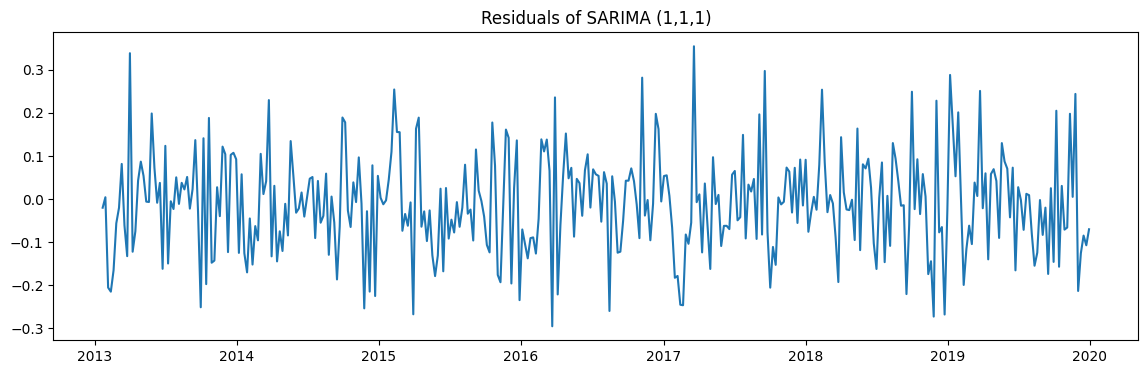

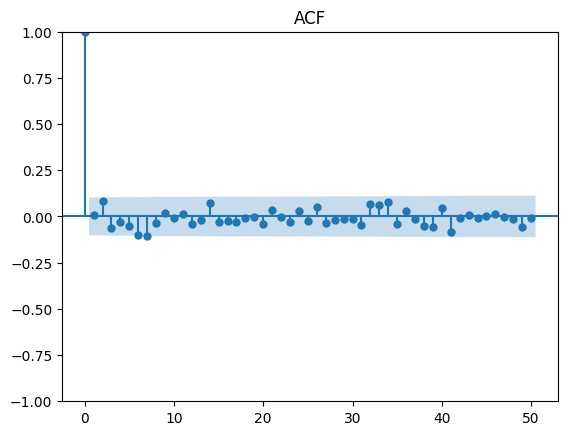


 Ljung Box
      lb_stat  lb_pvalue
10  14.037270   0.171298
20  18.491942   0.555036
30  21.932773   0.856478

Mean of residuals: -0.011096494879039952
Std of residuals: 0.11608722760648833
Relative mean (|mean| / std): 0.09558756038739052


In [18]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residuals of SARIMA (1,1,1)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 56


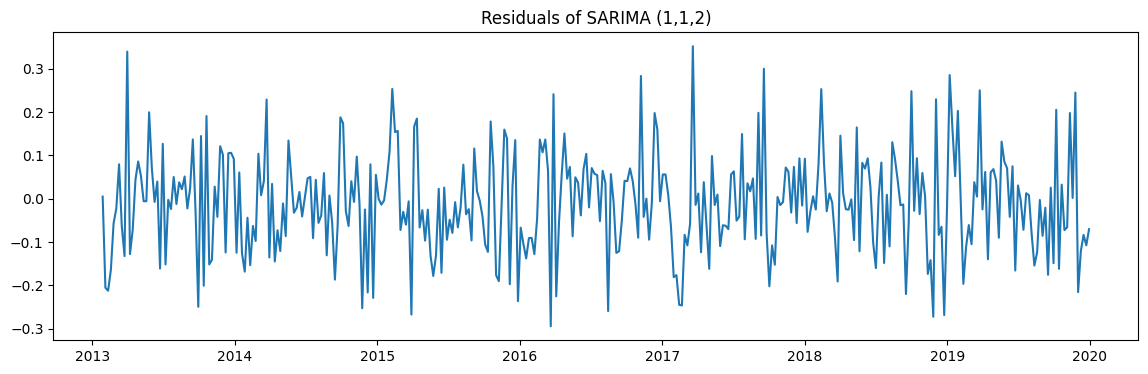

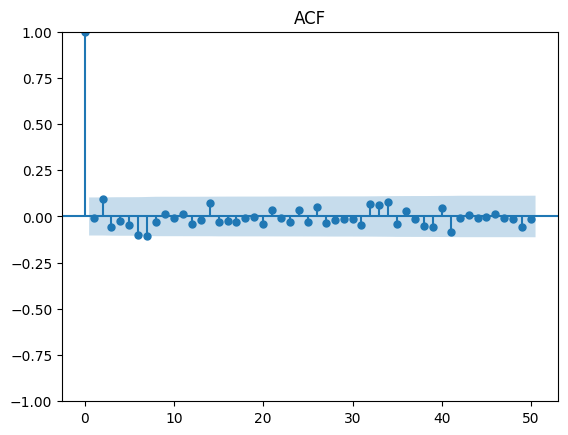


 Ljung Box
      lb_stat  lb_pvalue
10  13.726431   0.185840
20  18.220344   0.572896
30  21.716721   0.864148

Mean of residuals: -0.011086437990743115
Std of residuals: 0.11622480264350403
Relative mean (|mean| / std): 0.09538788398504329


In [19]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residuals of SARIMA (1,1,2)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 57


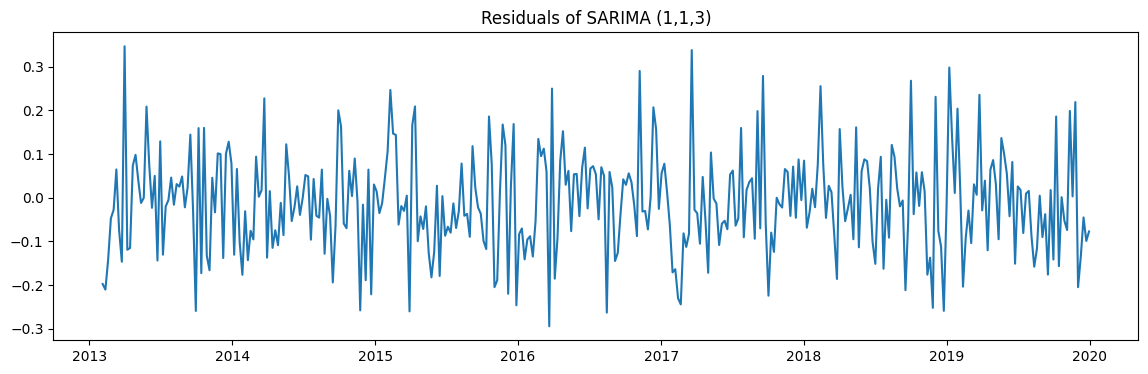

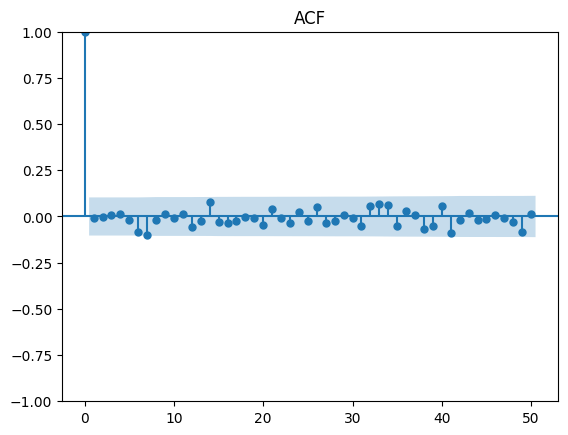


 Ljung Box
      lb_stat  lb_pvalue
10   6.925007   0.732505
20  12.685514   0.890466
30  16.008046   0.982675

Mean of residuals: -0.0110026635995206
Std of residuals: 0.11533961060888924
Relative mean (|mean| / std): 0.09539362532469502


In [20]:
residuals= result3.resid.dropna()
burn = max(result3.loglikelihood_burn, result3.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual3 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual3)
plt.title("Residuals of SARIMA (1,1,3)")
plt.show()

plot_acf(residual3, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual3, lags=[10, 20, 30], return_df=True))

mean_resid = residual3.mean()
std_resid = residual3.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

### Residual Validation Results

Residuals are analyzed to assess model adequacy.

For the three retained candidate models, residuals remain centered around zero and their overall behaviour is compatible with an approximately white-noise process. The residual autocorrelation is generally low, and the Ljung–Box results do not indicate important remaining dependence at the considered lags. 

Therefore, all three specifications provide acceptable residual diagnostics.
Since residual validation does not reveal substantial differences across the candidates, the final comparison is supported by the SARIMAX estimation output, the AIC values, and the MAE and RMSE obtained from the small backtesting exercise.


In [21]:
# Model 1
pred1 = result1.get_forecast(steps=len(test))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test, pred1_mean)
rmse1= root_mean_squared_error(test, pred1_mean)

# Model 2
pred2 = result2.get_forecast(steps=len(test))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test, pred2_mean)
rmse2= root_mean_squared_error(test, pred2_mean)

# Model 3
pred3 = result3.get_forecast(steps=len(test))
pred3_mean = pred3.predicted_mean

mae3 = mean_absolute_error(test, pred3_mean)
rmse3= root_mean_squared_error(test, pred3_mean)


print("Model (1,1,1)(0,1,0) → MAE:", mae1, "RMSE:", rmse1)
print("Model (1,1,2)(0,1,0) → MAE:", mae2, "RMSE:", rmse2)
print("Model (1,1,3)(0,1,0) → MAE:", mae3, "RMSE:", rmse3)

Model (1,1,1)(0,1,0) → MAE: 8257.322572252237 RMSE: 9421.540345407231
Model (1,1,2)(0,1,0) → MAE: 8257.323253168133 RMSE: 9421.540967081353
Model (1,1,3)(0,1,0) → MAE: 8257.329050677987 RMSE: 9421.546488016607


### Final Model Selection

Although the three candidate models show very similar residual behaviour and practically identical forecasting errors, the SARIMA(1,1,1)(0,1,0,52) model is preferred as the final specification.

This model attains the lowest AIC among the retained candidates and, unlike the more complex alternatives, all of its estimated coefficients are statistically significant. By contrast, the SARIMA(1,1,2)(0,1,0,52) and SARIMA(1,1,3)(0,1,0,52) models include additional moving-average terms that are not sufficiently supported by significance, while providing no meaningful improvement in predictive performance.

Therefore, the SARIMA(1,1,1)(0,1,0,52) model is selected as the final model, since it offers the best overall balance between goodness of fit, residual adequacy, and parsimony.

### Forecasting
Once the model has been validated, I generate forecasts using the test set horizon.

The objective is to evaluate how well the model captures:
- the overall trend
- the seasonal pattern
- the variability of the series

Predictions are accompanied by prediction intervals, which reflect the uncertainty of the model.

In [22]:
#Final model
model = SARIMAX(train_log,
                order=(1,1,1),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log) 

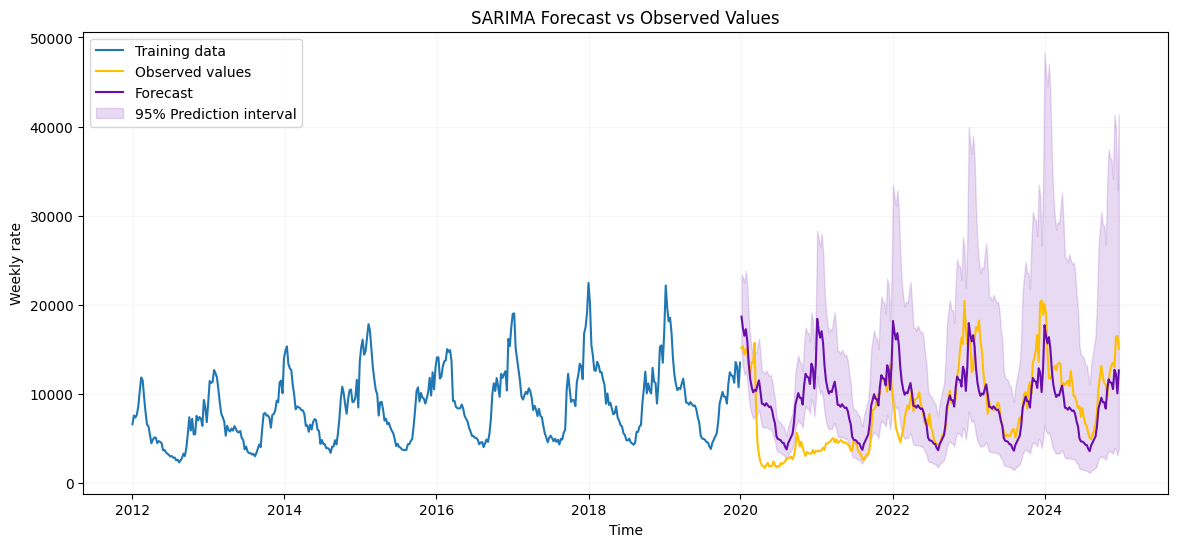

In [23]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Training data', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction interval')

plt.legend()
plt.title("SARIMA Forecast vs Observed Values")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)
plt.show()

In [24]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Coverage:", covTotal)

TOTAL
MAE: 3115.791299865945
RMSE: 4281.23330840727
Coverage: 0.7230769230769231


### Forecast Evaluation

To quantitatively evaluate the forecasting performance, I compute error metrics such as:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics measure the difference between observed and predicted values, allowing me to assess the accuracy of the model.

The empirical coverage of the 95% prediction intervals is about 0.72, which is below the nominal level and suggests that forecast uncertainty is underestimated.

To further investigate this issue, the test period is divided into two subperiods:
- COVID period
- Post-COVID period

This allows me to analyze whether the model behaves differently under structural changes in the data.

In [25]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Coverage:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)

cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Coverage:", cov_post)


COVID (2020-2021)
MAE: 4281.721522774116
RMSE: 5407.1539378016205
Coverage: 0.375

POST-COVID (2022-2024)
MAE: 2338.50448459383
RMSE: 3325.1649478340223
Coverage: 0.9551282051282052


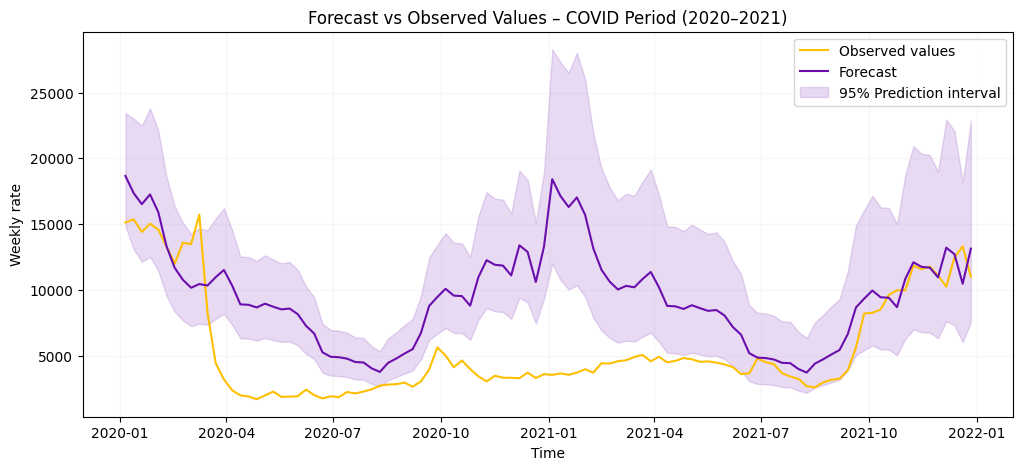

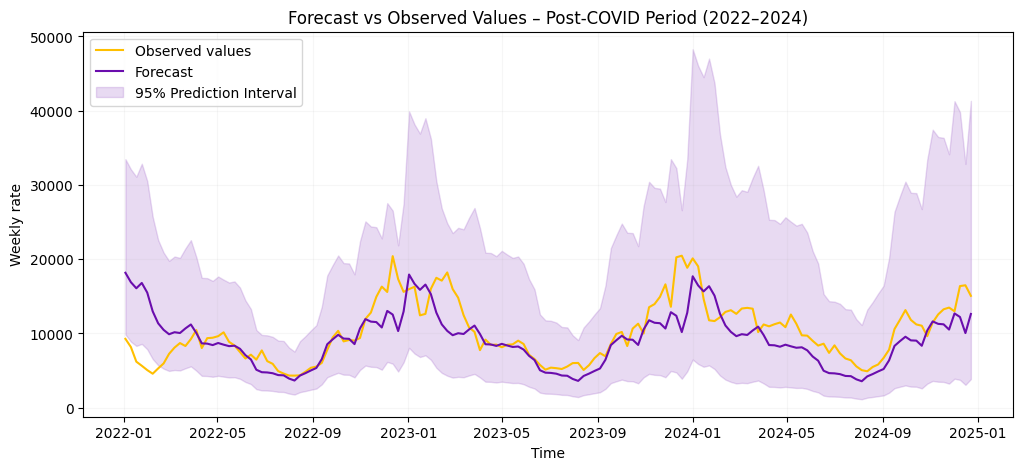

In [26]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction interval')

plt.title("Forecast vs Observed Values – COVID Period (2020–2021)")
plt.xlabel("Time")
plt.ylabel("Weekly rate") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction Interval')

plt.title("Forecast vs Observed Values – Post-COVID Period (2022–2024)")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

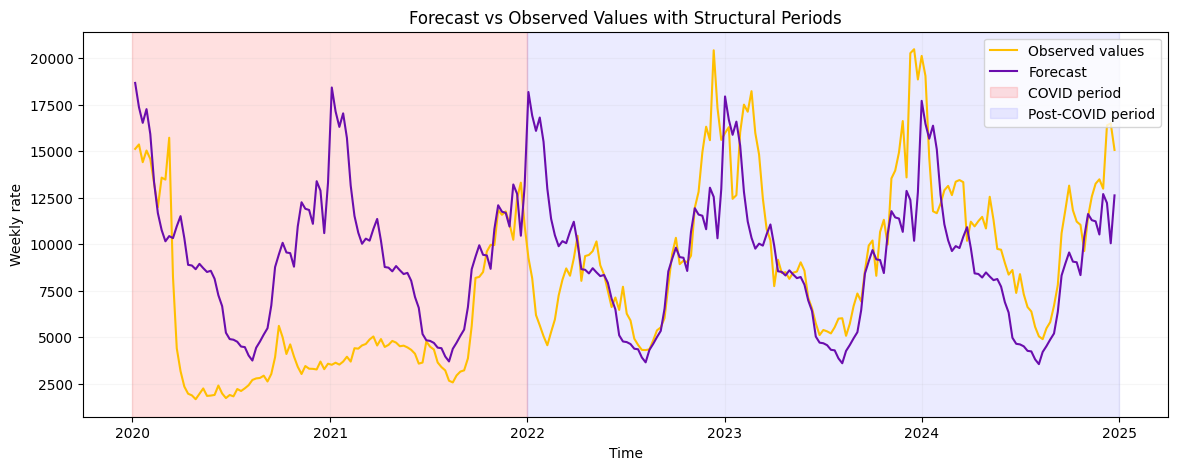

In [27]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='COVID period')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Post-COVID period')

plt.legend()
plt.title("Forecast vs Observed Values with Structural Periods")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)

plt.show()

### Visual Analysis

The model shows a clear difference in performance between the COVID period (2020–2021) and the post-COVID period (2022–2024).

During the COVID period, the forecast accuracy decreases significantly (higher MAE and RMSE), and the coverage drops to approximately 0.37. This reflects the inability of the model to capture the abrupt structural break caused by the pandemic, which lies outside the patterns learned from historical data.

In contrast, during the post-COVID period, the model recovers strong predictive performance, with lower errors and a coverage close to 0.95. This indicates that once the system stabilizes and returns to a more regular seasonal behavior, the SARIMA model is able to accurately capture the underlying dynamics.

These results highlight that the model is well-suited for regular conditions but also sensitive to structural disruptions, making it useful for detecting anomalous periods such as pandemics.